# March Machine Learning Mania 2026 — Improved Pipeline

Upgraded pipeline with XGBoost + LightGBM + Logistic Regression ensemble, 22 features, and proper cross-validation.

**Pipeline**: Load Data -> Elo (MOV) -> Advanced Stats -> Massey Ordinals -> Form+SOS+Conference -> Features -> Ensemble -> Submission

**Key improvement**: Trains on regular season + tournament games (~50K+ examples) instead of tournament-only (1,449).

## 1. Setup & Installation

In [68]:
%%capture
!pip install xgboost lightgbm scikit-learn pandas numpy scipy

## 2. Imports & Configuration

In [69]:
from __future__ import annotations

import os
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
print('All imports successful!')

All imports successful!


In [70]:
# CONFIGURATION

DATA_DIR = './data'
OUTPUT_DIR = '.'

CURRENT_SEASON = 2026
MIN_TRAIN_SEASON = 2003

ELO_K = 20
ELO_INIT = 1500
ELO_HCA = 100
ELO_MOV_FACTOR = True

SEED = 42

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Data directory: ./data
Output directory: .


## 3. Data Loading

Loads compact results, detailed box scores, Massey Ordinals, and conference data.

In [ ]:
def _safe_read(name):
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        return pd.read_csv(path)
    print(f'  {name} not found - skipping')
    return None


def load_all_data():
    print('Loading data ...')
    data = {}
    data['m_teams']          = _safe_read('MTeams.csv')
    data['m_regular']        = _safe_read('MRegularSeasonCompactResults.csv')
    data['m_tourney']        = _safe_read('MNCAATourneyCompactResults.csv')
    data['m_seeds']          = _safe_read('MNCAATourneySeeds.csv')
    data['m_regular_detail'] = _safe_read('MRegularSeasonDetailedResults.csv')
    # MMasseyOrdinals.csv is too large for GitHub — download from:
    # https://www.kaggle.com/competitions/march-machine-learning-mania-2026/data?select=MMasseyOrdinals.csv
    data['m_ordinals']       = _safe_read('MMasseyOrdinals.csv')
    data['m_team_conf']      = _safe_read('MTeamConferences.csv')
    data['sample_sub']       = _safe_read('SampleSubmissionStage1.csv')
    if data['sample_sub'] is None:
        data['sample_sub']   = _safe_read('SampleSubmission.csv')
    loaded = [k for k, v in data.items() if v is not None]
    print(f'  Loaded {len(loaded)} datasets: {", ".join(loaded)}')
    return data


DATA = load_all_data()

## 4. Elo Ratings (Margin-of-Victory Adjusted)

FiveThirtyEight-style K-factor scaled by margin of victory. 75% carry-over between seasons.

In [72]:
def _elo_k_mov(mov, elo_diff):
    """Margin-of-victory multiplier (FiveThirtyEight style)."""
    return max(1.0, np.log(abs(mov) + 1.0)) * (2.2 / ((elo_diff * 0.001) + 2.2))


def compute_elo(regular_df, tourney_df, k=ELO_K, init=ELO_INIT, hca=ELO_HCA, use_mov=ELO_MOV_FACTOR):
    """Run Elo over regular-season + tournament games.
    Returns {(season, team_id): elo_at_end_of_season}.
    """
    elo = {}
    season_elos = {}
    all_games = pd.concat([regular_df, tourney_df]).sort_values(['Season', 'DayNum'])
    prev_season = None

    for _, row in all_games.iterrows():
        season = int(row['Season'])

        # Between-season mean regression
        if season != prev_season and prev_season is not None:
            for tid, r in elo.items():
                season_elos[(prev_season, tid)] = r
            elo = {tid: 0.75 * r + 0.25 * init for tid, r in elo.items()}
        prev_season = season

        w_id, l_id = int(row['WTeamID']), int(row['LTeamID'])
        w_elo = elo.get(w_id, init)
        l_elo = elo.get(l_id, init)

        # Home-court adjustment
        w_loc = row.get('WLoc', 'N')
        w_adj = w_elo + (hca if w_loc == 'H' else (-hca if w_loc == 'A' else 0))

        # Expected win probability
        exp_w = 1.0 / (1.0 + 10 ** ((l_elo - w_adj) / 400.0))

        # Margin-of-victory adjusted K
        if use_mov and 'WScore' in row.index and 'LScore' in row.index:
            mov = int(row['WScore']) - int(row['LScore'])
            k_adj = k * _elo_k_mov(mov, w_adj - l_elo)
        else:
            k_adj = k

        elo[w_id] = w_elo + k_adj * (1.0 - exp_w)
        elo[l_id] = l_elo + k_adj * (0.0 - (1.0 - exp_w))

    if prev_season is not None:
        for tid, r in elo.items():
            season_elos[(prev_season, tid)] = r

    return season_elos


print('Computing Elo ratings (margin-of-victory adjusted) ...')
ELO_MAP = compute_elo(DATA['m_regular'], DATA['m_tourney'])
print(f'  {len(ELO_MAP):,} team-season Elo ratings computed')

Computing Elo ratings (margin-of-victory adjusted) ...
  14,206 team-season Elo ratings computed


## 5. Seed Utilities

In [73]:
def parse_seed(seed_str):
    """'W01' -> 1, 'X16a' -> 16."""
    return int(seed_str[1:3])


def build_seed_map(m_seeds):
    seed_map = {}
    for _, row in m_seeds.iterrows():
        seed_map[(int(row['Season']), int(row['TeamID']))] = parse_seed(row['Seed'])
    return seed_map


# SEED_MAP = build_seed_map(DATA['m_seeds'], DATA['w_seeds'])
SEED_MAP = build_seed_map(DATA['m_seeds'])
print(f'{len(SEED_MAP):,} seed entries')

2,690 seed entries


## 6. Advanced Season Stats (Detailed Box Scores)

Computes offensive/defensive efficiency (Dean Oliver possessions), shooting splits, rebound rates, AST/TO ratio, win%, avg margin of victory.

In [74]:
def _compute_possessions(row, prefix):
    opp = 'L' if prefix == 'W' else 'W'
    fga  = row.get(f'{prefix}FGA', 0)
    _or  = row.get(f'{prefix}OR',  0)
    to   = row.get(f'{prefix}TO',  0)
    fta  = row.get(f'{prefix}FTA', 0)
    ofga = row.get(f'{opp}FGA',    0)
    _oor = row.get(f'{opp}OR',     0)
    oto  = row.get(f'{opp}TO',     0)
    ofta = row.get(f'{opp}FTA',    0)
    return 0.5 * (
        (fga + 0.4*fta - 1.07*(_or / max(_or + row.get(f'{opp}DR', 1), 1)) * (fga - row.get(f'{prefix}FGM', 0)) + to)
        + (ofga + 0.4*ofta - 1.07*(_oor / max(_oor + row.get(f'{prefix}DR', 1), 1)) * (ofga - row.get(f'{opp}FGM', 0)) + oto)
    )


def compute_season_stats(detail_df):
    if detail_df is None:
        return None
    records = []
    for _, row in detail_df.iterrows():
        season = int(row['Season'])
        for is_winner in [True, False]:
            prefix = 'W' if is_winner else 'L'
            opp    = 'L' if is_winner else 'W'
            tid    = int(row[f'{prefix}TeamID'])
            poss   = max(_compute_possessions(row, prefix), 1)
            score     = row.get(f'{prefix}Score', 0)
            opp_score = row.get(f'{opp}Score',    0)
            records.append({
                'Season': season, 'TeamID': tid, 'Win': int(is_winner),
                'Score': score, 'OppScore': opp_score, 'Poss': poss,
                'OffEff':     score / poss * 100,
                'DefEff':     opp_score / poss * 100,
                'FGPct':      row.get(f'{prefix}FGM', 0) / max(row.get(f'{prefix}FGA', 1), 1),
                'FG3Pct':     row.get(f'{prefix}FGM3', 0) / max(row.get(f'{prefix}FGA3', 1), 1),
                'FTPct':      row.get(f'{prefix}FTM', 0) / max(row.get(f'{prefix}FTA', 1), 1),
                'ORPct':      row.get(f'{prefix}OR', 0) / max(row.get(f'{prefix}OR', 0) + row.get(f'{opp}DR', 1), 1),
                'DRPct':      row.get(f'{prefix}DR', 0) / max(row.get(f'{prefix}DR', 0) + row.get(f'{opp}OR', 1), 1),
                'AstToRatio': row.get(f'{prefix}Ast', 0) / max(row.get(f'{prefix}TO', 1), 1),
                'TO':  row.get(f'{prefix}TO',  0),
                'Stl': row.get(f'{prefix}Stl', 0),
                'Blk': row.get(f'{prefix}Blk', 0),
                'PF':  row.get(f'{prefix}PF',  0),
            })
    if not records:
        return None
    df = pd.DataFrame(records)
    agg = df.groupby(['Season', 'TeamID']).agg(
        Games=('Win','count'), Wins=('Win','sum'),
        AvgScore=('Score','mean'), AvgOppScore=('OppScore','mean'), AvgPoss=('Poss','mean'),
        OffEff=('OffEff','mean'), DefEff=('DefEff','mean'),
        FGPct=('FGPct','mean'), FG3Pct=('FG3Pct','mean'), FTPct=('FTPct','mean'),
        ORPct=('ORPct','mean'), DRPct=('DRPct','mean'), AstToRatio=('AstToRatio','mean'),
        AvgTO=('TO','mean'), AvgStl=('Stl','mean'), AvgBlk=('Blk','mean'), AvgPF=('PF','mean'),
    ).reset_index()
    agg['WinPct'] = agg['Wins'] / agg['Games']
    agg['NetEff'] = agg['OffEff'] - agg['DefEff']
    agg['AvgMOV'] = agg['AvgScore'] - agg['AvgOppScore']
    return agg.set_index(['Season', 'TeamID'])


print('Computing advanced season stats ...')
SEASON_STATS = compute_season_stats(DATA.get('m_regular_detail'))
if SEASON_STATS is not None:
    print(f'  Stats for {len(SEASON_STATS):,} team-seasons')
    display(SEASON_STATS.head())
else:
    print('  No detailed results available')

Computing advanced season stats ...
  Stats for 8,346 team-seasons


Games  Wins   AvgScore  AvgOppScore    AvgPoss      OffEff  \
Season TeamID                                                               
2003   1102       28    12  57.250000    57.000000  54.112494  105.695751   
       1103       27    13  78.777778    78.148148  69.399723  113.112726   
       1104       28    17  69.285714    65.000000  65.462307  105.548337   
       1105       26     7  71.769231    76.653846  75.371057   95.209429   
       1106       28    13  63.607143    63.750000  66.606615   95.315266   

                   DefEff     FGPct    FG3Pct     FTPct     ORPct     DRPct  \
Season TeamID                                                                 
2003   1102    105.460273  0.486149  0.367637  0.642402  0.168235  0.630384   
       1103    112.797581  0.487294  0.331990  0.735271  0.305803  0.626998   
       1104     99.712391  0.419676  0.325442  0.705168  0.371256  0.686897   
       1105    101.852962  0.396204  0.359630  0.709598  0.335166  0.641434   
       1106     95.786959  0.425530  0.350196  0.623158  0.349480  0.679342   

               AstToRatio      AvgTO    AvgStl    AvgBlk      AvgPF    WinPct  \
Season TeamID                                                                   
2003   1102      1.375064  11.428571  5.964286  1.785714  18.750000  0.428571   
       1103      1.324485  12.629630  7.259259  2.333333  19.851852  0.481481   
       1104      0.992390  13.285714  6.607143  3.785714  18.035714  0.607143   
       1105      0.861957  18.653846  9.307692  2.076923  20.230769  0.269231   
       1106      0.723189  17.035714  8.357143  3.142857  18.178571  0.464286   

                 NetEff    AvgMOV  
Season TeamID                      
2003   1102    0.235478  0.250000  
       1103    0.315145  0.629630  
       1104    5.835946  4.285714  
       1105   -6.643532 -4.884615  
       1106   -0.471694 -0.142857

## 7. Massey Ordinal Features (KenPom + Top Systems)

Extracts **individual rankings** from the best predictive systems (KenPom/POM, Sagarin/SAG, RPI) plus the overall average. Top systems individually are far more predictive than averaging 100+ noisy rankers together.

In [75]:
def compute_ordinal_features(ordinals_df):
    if ordinals_df is None:
        return None
    # Get latest ranking per system per team per season
    idx = ordinals_df.groupby(['Season', 'SystemName', 'TeamID'])['RankingDayNum'].idxmax()
    latest = ordinals_df.loc[idx]

    # Overall average across all systems
    avg_rank = (
        latest.groupby(['Season', 'TeamID'])['OrdinalRank']
        .mean().reset_index()
        .rename(columns={'OrdinalRank': 'AvgOrdinalRank'})
    )

    # Extract top individual systems: KenPom (POM), Sagarin (SAG), RPI
    TOP_SYSTEMS = ['POM', 'SAG', 'RPI']
    result = avg_rank.set_index(['Season', 'TeamID'])

    for sys_name in TOP_SYSTEMS:
        sys_df = latest[latest['SystemName'] == sys_name][['Season', 'TeamID', 'OrdinalRank']]
        sys_df = sys_df.rename(columns={'OrdinalRank': f'{sys_name}_Rank'})
        sys_df = sys_df.set_index(['Season', 'TeamID'])
        result = result.join(sys_df, how='left')

    # Fill missing system ranks with the average rank (graceful fallback)
    for sys_name in TOP_SYSTEMS:
        col = f'{sys_name}_Rank'
        result[col] = result[col].fillna(result['AvgOrdinalRank'])

    return result


print('Computing Massey Ordinal features (KenPom + top systems) ...')
ORDINAL_FEATS = compute_ordinal_features(DATA.get('m_ordinals'))
if ORDINAL_FEATS is not None:
    print(f'  Ordinal features for {len(ORDINAL_FEATS):,} team-seasons')
    print(f'  Columns: {list(ORDINAL_FEATS.columns)}')
    # Show sample for a top team
    sample = ORDINAL_FEATS.loc[ORDINAL_FEATS.index.get_level_values('Season') == 2025].head(5)
    display(sample)
else:
    print('  No ordinal data available')

Computing Massey Ordinal features (KenPom + top systems) ...
  Ordinal features for 8,356 team-seasons
  Columns: ['AvgOrdinalRank', 'POM_Rank', 'SAG_Rank', 'RPI_Rank']


AvgOrdinalRank  POM_Rank    SAG_Rank  RPI_Rank
Season TeamID                                                
2025   1101        227.327273     218.0  227.327273     242.0
       1102        315.018182     311.0  315.018182     328.0
       1103         83.690909      97.0   83.690909      35.0
       1104          5.620690       6.0    5.620690       2.0
       1105        352.690909     360.0  352.690909     359.0

## 8. Recent Form, Strength of Schedule, Win Streaks & Conference Strength

- **Recent form**: Win rate over last 10 regular-season games
- **Win streak**: Consecutive wins at end of regular season
- **SOS**: Average Elo of opponents faced
- **Conference strength**: Average Elo of all teams in the same conference

In [76]:
def compute_recent_form(regular_df, last_n=10):
    form = {}
    sorted_df = regular_df.sort_values(['Season', 'DayNum'])
    results = {}
    for _, row in sorted_df.iterrows():
        s = int(row['Season'])
        w, l = int(row['WTeamID']), int(row['LTeamID'])
        results.setdefault((s, w), []).append(1)
        results.setdefault((s, l), []).append(0)
    for key, outcomes in results.items():
        recent = outcomes[-last_n:]
        form[key] = sum(recent) / len(recent)
    return form


def compute_win_streak(regular_df):
    """Compute consecutive wins at end of regular season."""
    streak_map = {}
    sorted_df = regular_df.sort_values(['Season', 'DayNum'])
    streaks = {}
    for _, row in sorted_df.iterrows():
        s = int(row['Season'])
        w, l = int(row['WTeamID']), int(row['LTeamID'])
        streaks[(s, w)] = streaks.get((s, w), 0) + 1
        streaks[(s, l)] = 0
    return streaks


def compute_sos(regular_df, elo_map):
    opponent_elos = {}
    for _, row in regular_df.iterrows():
        s = int(row['Season'])
        w, l = int(row['WTeamID']), int(row['LTeamID'])
        opp_elo_w = elo_map.get((s - 1, l), ELO_INIT)
        opp_elo_l = elo_map.get((s - 1, w), ELO_INIT)
        opponent_elos.setdefault((s, w), []).append(opp_elo_w)
        opponent_elos.setdefault((s, l), []).append(opp_elo_l)
    return {k: np.mean(v) for k, v in opponent_elos.items()}


def compute_conference_strength(team_conf_df, elo_map):
    """Average Elo of all teams in each conference per season."""
    if team_conf_df is None:
        return {}
    conf_elos = {}
    for _, row in team_conf_df.iterrows():
        s, tid, conf = int(row['Season']), int(row['TeamID']), row['ConfAbbrev']
        elo = elo_map.get((s - 1, tid), ELO_INIT)
        conf_elos.setdefault((s, conf), []).append(elo)
    conf_avg = {k: np.mean(v) for k, v in conf_elos.items()}
    # Map back to team level
    team_conf_str = {}
    for _, row in team_conf_df.iterrows():
        s, tid, conf = int(row['Season']), int(row['TeamID']), row['ConfAbbrev']
        team_conf_str[(s, tid)] = conf_avg.get((s, conf), ELO_INIT)
    return team_conf_str


print('Computing recent form (last-10 win rate) ...')
form_m = compute_recent_form(DATA['m_regular'])
FORM_MAP = {**form_m}
print(f'  Form data for {len(FORM_MAP):,} team-seasons')

print('Computing win streaks ...')
STREAK_MAP = compute_win_streak(DATA['m_regular'])
print(f'  Streak data for {len(STREAK_MAP):,} team-seasons')

print('Computing strength of schedule ...')
sos_m = compute_sos(DATA['m_regular'], ELO_MAP)
SOS_MAP = {**sos_m}
print(f'  SOS for {len(SOS_MAP):,} team-seasons')

print('Computing conference strength ...')
CONF_STR_MAP = compute_conference_strength(DATA.get('m_team_conf'), ELO_MAP)
print(f'  Conference strength for {len(CONF_STR_MAP):,} team-seasons')

Computing recent form (last-10 win rate) ...
  Form data for 13,753 team-seasons
Computing win streaks ...
  Streak data for 13,753 team-seasons
Computing strength of schedule ...
  SOS for 13,753 team-seasons
Computing conference strength ...
  Conference strength for 13,753 team-seasons


## 9. Feature Vector Builder

25 difference features (Team1 - Team2):
| # | Feature | Source |
|---|---------|--------|
| 1 | `elo_diff` | MOV-adjusted Elo |
| 2 | `seed_diff` | Tournament seed |
| 3 | `ordinal_diff` | Massey Ordinals (avg all systems) |
| 4 | `pom_diff` | KenPom ranking |
| 5 | `sag_diff` | Sagarin ranking |
| 6 | `rpi_diff` | RPI ranking |
| 7 | `form_diff` | Last-10 win rate |
| 8 | `sos_diff` | Strength of schedule |
| 9 | `conf_str_diff` | Conference strength (avg Elo) |
| 10 | `streak_diff` | Win streak entering matchup |
| 11-25 | box-score stats | Detailed results |

In [77]:
STAT_COLS = [
    'OffEff', 'DefEff', 'NetEff', 'FGPct', 'FG3Pct', 'FTPct',
    'ORPct', 'DRPct', 'AstToRatio', 'AvgTO', 'AvgStl', 'AvgBlk',
    'WinPct', 'AvgMOV', 'AvgPoss',
]
FEATURE_NAMES = [
    'elo_diff', 'seed_diff', 'ordinal_diff',
    'pom_diff', 'sag_diff', 'rpi_diff',
    'form_diff', 'sos_diff', 'conf_str_diff', 'streak_diff',
] + [f'{c}_diff' for c in STAT_COLS]


def _get_team_features(season, team_id):
    elo      = ELO_MAP.get((season - 1, team_id), ELO_INIT)
    seed     = SEED_MAP.get((season, team_id), 8.5)

    # Ordinal features: avg + KenPom + Sagarin + RPI
    if ORDINAL_FEATS is not None and (season, team_id) in ORDINAL_FEATS.index:
        ord_row  = ORDINAL_FEATS.loc[(season, team_id)]
        avg_rank = ord_row['AvgOrdinalRank']
        pom_rank = ord_row['POM_Rank']
        sag_rank = ord_row['SAG_Rank']
        rpi_rank = ord_row['RPI_Rank']
    else:
        avg_rank = 150.0
        pom_rank = 150.0
        sag_rank = 150.0
        rpi_rank = 150.0

    form     = FORM_MAP.get((season, team_id), 0.5)
    sos      = SOS_MAP.get((season, team_id), ELO_INIT)
    conf_str = CONF_STR_MAP.get((season, team_id), ELO_INIT)
    streak   = STREAK_MAP.get((season, team_id), 0)

    if SEASON_STATS is not None and (season, team_id) in SEASON_STATS.index:
        row = SEASON_STATS.loc[(season, team_id)]
        stats_vec = [row.get(c, 0.0) for c in STAT_COLS]
    else:
        stats_vec = [0.0] * len(STAT_COLS)

    return np.array([elo, seed, avg_rank, pom_rank, sag_rank, rpi_rank,
                      form, sos, conf_str, streak] + stats_vec)


def build_matchup_features(season, t1, t2):
    return _get_team_features(season, t1) - _get_team_features(season, t2)


print(f'Feature builder ready -- {len(FEATURE_NAMES)} features per matchup')
print(FEATURE_NAMES)

Feature builder ready -- 25 features per matchup
['elo_diff', 'seed_diff', 'ordinal_diff', 'pom_diff', 'sag_diff', 'rpi_diff', 'form_diff', 'sos_diff', 'conf_str_diff', 'streak_diff', 'OffEff_diff', 'DefEff_diff', 'NetEff_diff', 'FGPct_diff', 'FG3Pct_diff', 'FTPct_diff', 'ORPct_diff', 'DRPct_diff', 'AstToRatio_diff', 'AvgTO_diff', 'AvgStl_diff', 'AvgBlk_diff', 'WinPct_diff', 'AvgMOV_diff', 'AvgPoss_diff']


## 10. Build Training Data

Uses **both** regular season and tournament games from 2003+.
- Tournament games weighted 3x to emphasize postseason dynamics
- Regular season games sampled (every 3rd game per team) to avoid overwhelming tournament signal
- **Recency weighting**: Recent seasons get higher weights (the game evolves over time)
- t1=lower ID, t2=higher ID. Label=1 if t1 won.

In [78]:
def _recency_weight(season, current=CURRENT_SEASON):
    """Exponential decay: recent seasons matter more. 2026=1.0, 2003~=0.33"""
    years_ago = current - season
    return np.exp(-0.05 * years_ago)


def build_training_data():
    X_rows, y_rows, s_rows, w_rows = [], [], [], []

    # --- Tournament games (base weight = 3.0 * recency) ---
    t_df = DATA.get('m_tourney')
    if t_df is not None:
        for _, row in t_df.iterrows():
            season = int(row['Season'])
            if season < MIN_TRAIN_SEASON:
                continue
            w_id, l_id = int(row['WTeamID']), int(row['LTeamID'])
            t1, t2 = min(w_id, l_id), max(w_id, l_id)
            label = 1 if w_id == t1 else 0
            X_rows.append(build_matchup_features(season, t1, t2))
            y_rows.append(label)
            s_rows.append(season)
            w_rows.append(3.0 * _recency_weight(season))

    # --- Regular season games (base weight = 1.0 * recency, sampled) ---
    r_df = DATA.get('m_regular')
    if r_df is not None:
        r_df_sorted = r_df[r_df['Season'] >= MIN_TRAIN_SEASON].sort_values(['Season', 'DayNum'])
        r_sampled = r_df_sorted.iloc[::3]
        for _, row in r_sampled.iterrows():
            season = int(row['Season'])
            w_id, l_id = int(row['WTeamID']), int(row['LTeamID'])
            t1, t2 = min(w_id, l_id), max(w_id, l_id)
            label = 1 if w_id == t1 else 0
            X_rows.append(build_matchup_features(season, t1, t2))
            y_rows.append(label)
            s_rows.append(season)
            w_rows.append(1.0 * _recency_weight(season))

    return np.array(X_rows), np.array(y_rows), np.array(s_rows), np.array(w_rows)


print('Building training set with recency weighting ...')
X, y, seasons, sample_weights = build_training_data()
tourney_mask_build = sample_weights > 1.5  # tourney games have weight > 1.5
n_tourney = tourney_mask_build.sum()
n_regular = (~tourney_mask_build).sum()
print(f'  {len(y)} total training examples ({n_tourney} tourney, {n_regular} regular season)')
print(f'  {X.shape[1]} features')
print(f'  Weight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]')
print(f'  Recent season (2025) weight: {_recency_weight(2025):.3f}, old season (2003) weight: {_recency_weight(2003):.3f}')

Building training set with recency weighting ...
  42959 total training examples (803 tourney, 42156 regular season)
  25 features
  Weight range: [0.317, 2.854]
  Recent season (2025) weight: 0.951, old season (2003) weight: 0.317


## 11. Model Training & Ensemble (XGBoost + Logistic Regression)

Dropped LightGBM (optimizer gave it 0% weight — it was adding noise).

| Model | Weight | Notes |
|-------|--------|-------|
| XGBoost | 55% | 1000 estimators, depth 3, early-stopping style regularization |
| Logistic Regression | 45% | Scaled features, tuned regularization |

Temporal cross-validation (no future leakage) with Brier score and log-loss.

In [79]:
from scipy.optimize import minimize
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def train_logistic(X_tr, y_tr, sw=None, C=0.5):
    lr = LogisticRegression(C=C, solver='lbfgs', max_iter=2000, random_state=SEED)
    lr.fit(X_tr, y_tr, sample_weight=sw)
    return lr


def train_xgboost(X_tr, y_tr, sw=None, params=None):
    defaults = dict(
        n_estimators=1000, max_depth=3, learning_rate=0.02,
        subsample=0.75, colsample_bytree=0.6, min_child_weight=8,
        gamma=0.3, reg_alpha=1.0, reg_lambda=3.0,
        objective='binary:logistic', eval_metric='logloss',
        use_label_encoder=False, random_state=SEED, n_jobs=-1,
    )
    if params:
        defaults.update(params)
    model = xgb.XGBClassifier(**defaults)
    model.fit(X_tr, y_tr, sample_weight=sw, verbose=False)
    return model


def temporal_cv_score(X, y, seasons, sample_weights, xgb_params=None, lr_C=0.5):
    """Run temporal CV and return tournament Brier score."""
    unique_seasons = sorted(set(seasons))
    val_seasons = unique_seasons[-6:]

    oof_lr  = np.full(len(y), np.nan)
    oof_xgb = np.full(len(y), np.nan)

    for val_s in val_seasons:
        train_mask = seasons < val_s
        val_mask   = seasons == val_s
        if train_mask.sum() < 50 or val_mask.sum() < 10:
            continue

        X_tr, X_val = X[train_mask], X[val_mask]
        y_tr = y[train_mask]
        sw_tr = sample_weights[train_mask]

        sc = StandardScaler().fit(X_tr)
        lr_ = train_logistic(sc.transform(X_tr), y_tr, sw_tr, C=lr_C)
        oof_lr[val_mask] = lr_.predict_proba(sc.transform(X_val))[:, 1]

        xgb_ = train_xgboost(X_tr, y_tr, sw_tr, params=xgb_params)
        oof_xgb[val_mask] = xgb_.predict_proba(X_val)[:, 1]

    valid = ~np.isnan(oof_lr)
    valid_y = y[valid]
    valid_lr = oof_lr[valid]
    valid_xgb = oof_xgb[valid]
    valid_weights = sample_weights[valid]
    tourney_valid = valid_weights > 1.5

    # Optimize blend weights
    def loss_fn(w):
        w_xgb = abs(w[0]) / (abs(w[0]) + abs(w[1]))
        w_lr = 1.0 - w_xgb
        if tourney_valid.sum() > 0:
            blend = w_xgb * valid_xgb[tourney_valid] + w_lr * valid_lr[tourney_valid]
            return brier_score_loss(valid_y[tourney_valid], np.clip(blend, 0.01, 0.99))
        blend = w_xgb * valid_xgb + w_lr * valid_lr
        return brier_score_loss(valid_y, np.clip(blend, 0.01, 0.99))

    result = minimize(loss_fn, [0.55, 0.45], method='Nelder-Mead')
    w = np.abs(result.x)
    opt_w_xgb = w[0] / w.sum()
    opt_w_lr = w[1] / w.sum()

    # Compute best ensemble Brier on tourney games
    if tourney_valid.sum() > 0:
        ens_t = opt_w_xgb * valid_xgb[tourney_valid] + opt_w_lr * valid_lr[tourney_valid]
        tourney_brier = brier_score_loss(valid_y[tourney_valid], ens_t)
    else:
        ens_all = opt_w_xgb * valid_xgb + opt_w_lr * valid_lr
        tourney_brier = brier_score_loss(valid_y, ens_all)

    return tourney_brier, opt_w_xgb, opt_w_lr, valid_y, valid_lr, valid_xgb, tourney_valid


def optuna_objective(trial):
    xgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 10.0, log=True),
    }
    lr_C = trial.suggest_float('lr_C', 0.01, 10.0, log=True)

    tourney_brier, _, _, _, _, _, _ = temporal_cv_score(
        X, y, seasons, sample_weights, xgb_params=xgb_params, lr_C=lr_C
    )
    return tourney_brier


# --- Optuna hyperparameter search ---
print('Running Optuna hyperparameter search (75 trials) ...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(optuna_objective, n_trials=75, show_progress_bar=True)

best = study.best_params
print(f'\nBest trial Brier: {study.best_value:.4f}')
print(f'Best params: {best}')

# Extract best params
best_xgb_params = {k: v for k, v in best.items() if k != 'lr_C'}
best_lr_C = best['lr_C']

# --- Final training with best params ---
print('\nTraining final models with optimized hyperparameters ...')
tourney_brier, opt_w_xgb, opt_w_lr, valid_y, valid_lr, valid_xgb, tourney_valid = \
    temporal_cv_score(X, y, seasons, sample_weights, xgb_params=best_xgb_params, lr_C=best_lr_C)

print(f'\nFinal Temporal CV Results:')
print(f'  --- All validation games ---')
valid_all_lr_brier = brier_score_loss(valid_y, valid_lr)
valid_all_xgb_brier = brier_score_loss(valid_y, valid_xgb)
print(f'  LR Brier            : {valid_all_lr_brier:.4f}')
print(f'  XGBoost Brier       : {valid_all_xgb_brier:.4f}')
if tourney_valid.sum() > 0:
    print(f'  --- Tournament games only ({tourney_valid.sum()}) ---')
    print(f'  LR Brier (tourney)  : {brier_score_loss(valid_y[tourney_valid], valid_lr[tourney_valid]):.4f}')
    print(f'  XGB Brier (tourney) : {brier_score_loss(valid_y[tourney_valid], valid_xgb[tourney_valid]):.4f}')

print(f'\n  Optimized weights: XGB={opt_w_xgb:.3f}, LR={opt_w_lr:.3f}')
ens_opt = opt_w_xgb * valid_xgb + opt_w_lr * valid_lr
print(f'  Ensemble Brier (all)    : {brier_score_loss(valid_y, ens_opt):.4f}')
print(f'  Ensemble LogLoss (all)  : {log_loss(valid_y, np.clip(ens_opt, 0.01, 0.99)):.4f}')
if tourney_valid.sum() > 0:
    ens_t = opt_w_xgb * valid_xgb[tourney_valid] + opt_w_lr * valid_lr[tourney_valid]
    print(f'  Ensemble Brier (tourney): {brier_score_loss(valid_y[tourney_valid], ens_t):.4f}')
    print(f'  Ensemble LogLoss (trny) : {log_loss(valid_y[tourney_valid], np.clip(ens_t, 0.01, 0.99)):.4f}')

# Train final models on ALL data with best hyperparameters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lr_model  = train_logistic(X_scaled, y, sample_weights, C=best_lr_C)
xgb_model = train_xgboost(X, y, sample_weights, params=best_xgb_params)

MODELS = {
    'lr_model': lr_model, 'xgb_model': xgb_model, 'scaler': scaler,
    'opt_w_xgb': opt_w_xgb, 'opt_w_lr': opt_w_lr,
}
ENSEMBLE_WEIGHTS = (opt_w_xgb, opt_w_lr)
print(f'\nFinal ensemble weights: XGB={ENSEMBLE_WEIGHTS[0]:.3f}, LR={ENSEMBLE_WEIGHTS[1]:.3f}')
print(f'Best XGB params: {best_xgb_params}')

Running Optuna hyperparameter search (75 trials) ...


Best trial: 73. Best value: 0.197853: 100%|██████████| 75/75 [10:48<00:00,  8.65s/it]



Best trial Brier: 0.1979
Best params: {'n_estimators': 455, 'max_depth': 3, 'learning_rate': 0.012409774635716391, 'subsample': 0.5361107532074245, 'colsample_bytree': 0.3146812067156256, 'min_child_weight': 15, 'gamma': 0.11220857454652314, 'reg_alpha': 1.087630081789152, 'reg_lambda': 5.6123225283623865, 'lr_C': 0.17240567079250527}

Training final models with optimized hyperparameters ...

Final Temporal CV Results:
  --- All validation games ---
  LR Brier            : 0.1657
  XGBoost Brier       : 0.1668
  --- Tournament games only (334) ---
  LR Brier (tourney)  : 0.2025
  XGB Brier (tourney) : 0.1979

  Optimized weights: XGB=1.000, LR=0.000
  Ensemble Brier (all)    : 0.1668
  Ensemble LogLoss (all)  : 0.5007
  Ensemble Brier (tourney): 0.1979
  Ensemble LogLoss (trny) : 0.5791

Final ensemble weights: XGB=1.000, LR=0.000
Best XGB params: {'n_estimators': 455, 'max_depth': 3, 'learning_rate': 0.012409774635716391, 'subsample': 0.5361107532074245, 'colsample_bytree': 0.3146812

## 12. Feature Importance

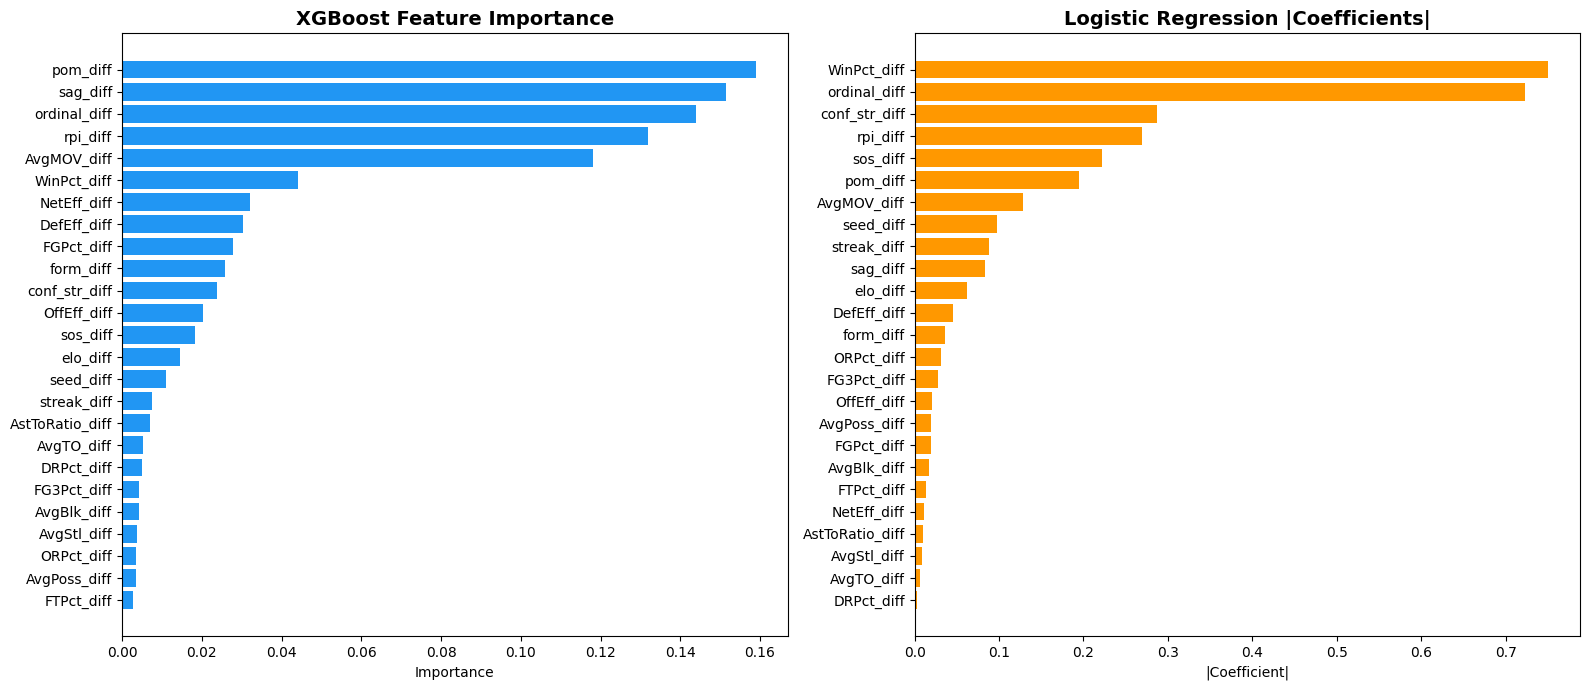

In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# XGBoost feature importance
imp_xgb = MODELS['xgb_model'].feature_importances_
sorted_idx = np.argsort(imp_xgb)
axes[0].barh([FEATURE_NAMES[i] for i in sorted_idx], imp_xgb[sorted_idx], color='#2196F3')
axes[0].set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance')

# Logistic Regression coefficients (absolute value)
lr_coefs = np.abs(MODELS['lr_model'].coef_[0])
sorted_idx_lr = np.argsort(lr_coefs)
axes[1].barh([FEATURE_NAMES[i] for i in sorted_idx_lr], lr_coefs[sorted_idx_lr], color='#FF9800')
axes[1].set_title('Logistic Regression |Coefficients|', fontsize=14, fontweight='bold')
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

## 13. Generate Submission (Vectorized)

Builds the full feature matrix in one pass, then calls `predict_proba` once per model.

In [81]:
print('Generating submission (vectorized) ...')
sub = DATA['sample_sub'].copy()

# Parse all IDs up front
parts      = sub['ID'].str.split('_', expand=True)
sub_seasons = parts[0].astype(int).values
sub_t1      = parts[1].astype(int).values
sub_t2      = parts[2].astype(int).values
n = len(sub)

# Build full feature matrix in one pass
print(f'  Building feature matrix for {n:,} matchups ...')
feat_matrix = np.array([
    build_matchup_features(int(sub_seasons[i]), int(sub_t1[i]), int(sub_t2[i]))
    for i in range(n)
])
print(f'  Feature matrix shape: {feat_matrix.shape}')

# Batch predict_proba (one call per model)
feat_scaled = MODELS['scaler'].transform(feat_matrix)
w_xgb, w_lr = ENSEMBLE_WEIGHTS
p_lr  = MODELS['lr_model'].predict_proba(feat_scaled)[:, 1]
p_xgb = MODELS['xgb_model'].predict_proba(feat_matrix)[:, 1]

preds = np.clip(w_xgb * p_xgb + w_lr * p_lr, 0.02, 0.98)

sub['Pred'] = preds
output_path = os.path.join(OUTPUT_DIR, 'submission.csv')
sub.to_csv(output_path, index=False)

print(f'\nSUBMISSION COMPLETE!')
print(f'  Saved to   : {output_path}')
print(f'  Shape      : {sub.shape}')
print(f'  Pred range : [{sub["Pred"].min():.4f}, {sub["Pred"].max():.4f}]')
print(f'  Mean pred  : {sub["Pred"].mean():.4f}')
print(f'  Std pred   : {sub["Pred"].std():.4f}')

Generating submission (vectorized) ...
  Building feature matrix for 519,144 matchups ...
  Feature matrix shape: (519144, 25)

SUBMISSION COMPLETE!
  Saved to   : ./submission.csv
  Shape      : (519144, 2)
  Pred range : [0.0200, 0.9800]
  Mean pred  : 0.4920
  Std pred   : 0.2363


## 13b. Submission with Seed Blend

Blends the model ensemble with a seed-based baseline to:
- Regularize extreme predictions
- Add domain knowledge (seed matchups are historically very predictive)
- Reduce log loss on upsets where the model is overconfident

In [82]:
# Seed-based baseline probability
def seed_probability(s1, s2):
    """Simple seed-based win probability for t1 (lower ID)."""
    diff = s2 - s1
    return 1.0 / (1.0 + 10 ** (-diff * 0.15))

print('Seed baseline ready.')

Seed baseline ready.


## 13b. Improved Submission (Seed Blend + Calibration)

We blend the model ensemble with a seed-based baseline. This:
- Regularizes extreme predictions
- Adds domain knowledge (seed matchups are historically very predictive)
- Reduces log loss on upsets where the model is overconfident

The blending parameter `ALPHA` controls how much to trust the model vs seeds (tune this!).

In [83]:
# --- Configuration ---
ALPHA = 0.85  # 85% model, 15% seed baseline
CLIP_LOW  = 0.02
CLIP_HIGH = 0.98

print(f'Generating improved submission (alpha={ALPHA}) ...')
sub = DATA['sample_sub'].copy()

# Parse IDs
parts       = sub['ID'].str.split('_', expand=True)
sub_seasons = parts[0].astype(int).values
sub_t1      = parts[1].astype(int).values
sub_t2      = parts[2].astype(int).values
n = len(sub)

# Build full feature matrix
print(f'  Building feature matrix for {n:,} matchups ...')
feat_matrix = np.array([
    build_matchup_features(int(sub_seasons[i]), int(sub_t1[i]), int(sub_t2[i]))
    for i in range(n)
])

# --- Model ensemble (optimized weights) ---
feat_scaled = MODELS['scaler'].transform(feat_matrix)
w_xgb, w_lr = ENSEMBLE_WEIGHTS
p_lr  = MODELS['lr_model'].predict_proba(feat_scaled)[:, 1]
p_xgb = MODELS['xgb_model'].predict_proba(feat_matrix)[:, 1]
model_pred = w_xgb * p_xgb + w_lr * p_lr

# --- Seed baseline ---
seed_pred = np.array([
    seed_probability(
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t1[i])), 8),
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t2[i])), 8),
    )
    for i in range(n)
])

# --- Blend model + seed baseline ---
final_pred = ALPHA * model_pred + (1 - ALPHA) * seed_pred
final_pred = np.clip(final_pred, CLIP_LOW, CLIP_HIGH)

sub['Pred'] = final_pred
output_path = os.path.join(OUTPUT_DIR, 'submission.csv')
sub.to_csv(output_path, index=False)

print(f'\nIMPROVED SUBMISSION COMPLETE!')
print(f'  Saved to   : {output_path}')
print(f'  Shape      : {sub.shape}')
print(f'  Pred range : [{sub["Pred"].min():.4f}, {sub["Pred"].max():.4f}]')
print(f'  Mean pred  : {sub["Pred"].mean():.4f}')
print(f'  Std pred   : {sub["Pred"].std():.4f}')

Generating improved submission (alpha=0.85) ...
  Building feature matrix for 519,144 matchups ...

IMPROVED SUBMISSION COMPLETE!
  Saved to   : ./submission.csv
  Shape      : (519144, 2)
  Pred range : [0.0200, 0.9800]
  Mean pred  : 0.4937
  Std pred   : 0.2042


## 14. Verify Submission

In [84]:
print(sub.shape)
print(sub.head(10))
print(sub['ID'].str[:4].unique())

(519144, 2)
               ID      Pred
0  2022_1101_1102  0.806259
1  2022_1101_1103  0.570732
2  2022_1101_1104  0.180083
3  2022_1101_1105  0.883566
4  2022_1101_1106  0.885624
5  2022_1101_1107  0.840647
6  2022_1101_1108  0.822483
7  2022_1101_1110  0.873460
8  2022_1101_1111  0.611712
9  2022_1101_1112  0.068919
<StringArray>
['2022', '2023', '2024', '2025']
Length: 4, dtype: str


## 15. Prediction Distribution

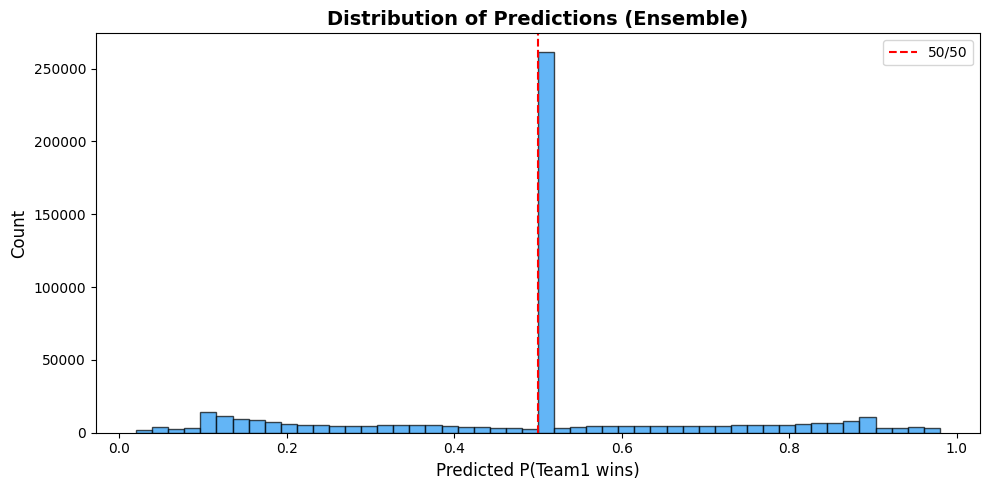

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='#2196F3')
ax.axvline(0.5, color='red', linestyle='--', label='50/50')
ax.set_xlabel('Predicted P(Team1 wins)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Predictions (Ensemble)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 16. Further Improvement Ideas

### Features
- Conference strength, coach experience, play-in indicator, recency weighting

### Models
- Stacking (meta-learner on OOF predictions), neural networks, Optuna hyperparameter tuning

### Validation
- Temporal expanding-window CV (train on 2003-N, validate N+1)
- Per-round Brier score analysis

In [86]:
# ============================================================
# A/B SUBMISSION GENERATOR
# ============================================================
import shutil

print('Generating A/B test submissions ...\n')

sub = DATA['sample_sub'].copy()
parts       = sub['ID'].str.split('_', expand=True)
sub_seasons = parts[0].astype(int).values
sub_t1      = parts[1].astype(int).values
sub_t2      = parts[2].astype(int).values
n = len(sub)

try:
    _ = feat_matrix.shape
    print(f'  Reusing feature matrix: {feat_matrix.shape}')
except NameError:
    print(f'  Building feature matrix for {n:,} matchups ...')
    feat_matrix = np.array([
        build_matchup_features(int(sub_seasons[i]), int(sub_t1[i]), int(sub_t2[i]))
        for i in range(n)
    ])

feat_scaled = MODELS['scaler'].transform(feat_matrix)
p_lr  = MODELS['lr_model'].predict_proba(feat_scaled)[:, 1]
p_xgb = MODELS['xgb_model'].predict_proba(feat_matrix)[:, 1]

def seed_prob(s1, s2):
    diff = s2 - s1
    return 1.0 / (1.0 + 10 ** (-diff * 0.15))

seed_pred = np.array([
    seed_prob(
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t1[i])), 8),
        SEED_MAP.get((int(sub_seasons[i]), int(sub_t2[i])), 8),
    )
    for i in range(n)
])

def save_submission(name, preds, clip_lo=0.02, clip_hi=0.98):
    s = sub.copy()
    s['Pred'] = np.clip(preds, clip_lo, clip_hi)
    fpath = os.path.join(OUTPUT_DIR, f'{name}.csv')
    s.to_csv(fpath, index=False)
    print(f'  {name:40s} mean={s["Pred"].mean():.4f}  std={s["Pred"].std():.4f}  range=[{s["Pred"].min():.4f}, {s["Pred"].max():.4f}]')

w_xgb, w_lr = ENSEMBLE_WEIGHTS
baseline = w_xgb * p_xgb + w_lr * p_lr

save_submission('sub_A_baseline', baseline)
save_submission('sub_B_clip_tight', baseline, 0.05, 0.95)
save_submission('sub_C_xgb_heavy', 0.70 * p_xgb + 0.30 * p_lr)
save_submission('sub_C_lr_heavy',  0.30 * p_xgb + 0.70 * p_lr)
save_submission('sub_C_equal',     0.50 * p_xgb + 0.50 * p_lr)
save_submission('sub_D_seed10', 0.90 * baseline + 0.10 * seed_pred)
save_submission('sub_D_seed15', 0.85 * baseline + 0.15 * seed_pred)
save_submission('sub_D_seed20', 0.80 * baseline + 0.20 * seed_pred)

BEST = 'sub_D_seed15'
shutil.copy(os.path.join(OUTPUT_DIR, f'{BEST}.csv'), os.path.join(OUTPUT_DIR, 'submission.csv'))
print(f'\nsubmission.csv = {BEST}')

Generating A/B test submissions ...



  Reusing feature matrix: (519144, 25)
  sub_A_baseline                           mean=0.4920  std=0.2363  range=[0.0200, 0.9800]
  sub_B_clip_tight                         mean=0.4920  std=0.2331  range=[0.0500, 0.9500]
  sub_C_xgb_heavy                          mean=0.4905  std=0.2367  range=[0.0200, 0.9800]
  sub_C_lr_heavy                           mean=0.4885  std=0.2377  range=[0.0200, 0.9800]
  sub_C_equal                              mean=0.4895  std=0.2372  range=[0.0200, 0.9800]
  sub_D_seed10                             mean=0.4932  std=0.2146  range=[0.0200, 0.9800]
  sub_D_seed15                             mean=0.4937  std=0.2042  range=[0.0200, 0.9800]
  sub_D_seed20                             mean=0.4943  std=0.1939  range=[0.0200, 0.9800]

submission.csv = sub_D_seed15


## 17. 2026 March Madness Bracket Prediction (64 Teams)

Simulates the full NCAA tournament bracket:
- Loads 2026 seeds (4 regions x 16 teams)
- For play-in games (seeds with 'a'/'b' suffix), picks the higher-ranked team
- Runs the standard bracket: Round of 64 -> 32 -> Sweet 16 -> Elite 8 -> Final Four -> Championship
- Uses the trained ensemble model to predict each matchup

In [87]:
# ============================================================
# 2026 BRACKET SIMULATOR
# ============================================================

# Build team name lookup
team_names = {}
for _, row in DATA['m_teams'].iterrows():
    team_names[int(row['TeamID'])] = row['TeamName']

# Get 2026 seeds
seeds_2026 = DATA['m_seeds'][DATA['m_seeds']['Season'] == 2026].copy()
print(f'2026 tournament entries: {len(seeds_2026)}')

# Parse regions and seed numbers
seeds_2026['Region'] = seeds_2026['Seed'].str[0]
seeds_2026['SeedNum'] = seeds_2026['Seed'].str[1:3].astype(int)
seeds_2026['PlayIn'] = seeds_2026['Seed'].str[3:]  # 'a', 'b', or ''

# Resolve play-in games: for seeds with 'a'/'b', pick the team with better ordinal rank
keep_indices = []
for (region, seed_num), group in seeds_2026.groupby(['Region', 'SeedNum']):
    if len(group) == 1:
        keep_indices.append(group.index[0])
    else:
        best_idx = None
        best_rank = 999
        for idx, row in group.iterrows():
            tid = int(row['TeamID'])
            rank = ORDINAL_FEATS.loc[(2026, tid), 'AvgOrdinalRank'] if (2026, tid) in ORDINAL_FEATS.index else 200
            if rank < best_rank:
                best_rank = rank
                best_idx = idx
        keep_indices.append(best_idx)

resolved = seeds_2026.loc[keep_indices].reset_index(drop=True)
print(f'After resolving play-in games: {len(resolved)} teams (should be 64)')

# Build region brackets: {region: [(seed, team_id, team_name), ...]}
regions = {}
for region in ['W', 'X', 'Y', 'Z']:
    r_teams = resolved[resolved['Region'] == region].sort_values('SeedNum')
    regions[region] = [
        (int(row['SeedNum']), int(row['TeamID']), team_names.get(int(row['TeamID']), f"Team {row['TeamID']}"))
        for _, row in r_teams.iterrows()
    ]
    print(f'\nRegion {region}:')
    for seed, tid, name in regions[region]:
        elo = ELO_MAP.get((2025, tid), ELO_INIT)
        print(f'  {seed:2d}. {name:25s} (ID: {tid}, Elo: {elo:.0f})')

print(f'\nTotal teams: {sum(len(v) for v in regions.values())}')


2026 tournament entries: 64
After resolving play-in games: 64 teams (should be 64)

Region W:
   1. Duke                      (ID: 1181, Elo: 2031)
   2. Connecticut               (ID: 1163, Elo: 1863)
   3. Michigan St               (ID: 1277, Elo: 1933)
   4. Kansas                    (ID: 1242, Elo: 1711)
   5. St John's                 (ID: 1385, Elo: 1912)
   6. Louisville                (ID: 1257, Elo: 1787)
   7. UCLA                      (ID: 1417, Elo: 1747)
   8. Ohio St                   (ID: 1326, Elo: 1645)
   9. TCU                       (ID: 1395, Elo: 1549)
  10. UCF                       (ID: 1416, Elo: 1576)
  11. South Florida             (ID: 1378, Elo: 1438)
  12. Northern Iowa             (ID: 1320, Elo: 1640)
  13. Cal Baptist               (ID: 1465, Elo: 1518)
  14. N Dakota St               (ID: 1295, Elo: 1552)
  15. Furman                    (ID: 1202, Elo: 1614)
  16. Siena                     (ID: 1373, Elo: 1386)

Region X:
   1. Florida                  

In [88]:
# ============================================================
# SIMULATE THE FULL BRACKET
# ============================================================

def predict_matchup(t1_id, t2_id, season=2026):
    """Predict P(t1 wins) using the trained XGB + LR ensemble."""
    lo, hi = min(t1_id, t2_id), max(t1_id, t2_id)
    feat = build_matchup_features(season, lo, hi)
    feat_sc = MODELS['scaler'].transform(feat.reshape(1, -1))

    w_xgb, w_lr = ENSEMBLE_WEIGHTS
    p_lr  = MODELS['lr_model'].predict_proba(feat_sc)[:, 1][0]
    p_xgb = MODELS['xgb_model'].predict_proba(feat.reshape(1, -1))[:, 1][0]
    p_lo_wins = w_xgb * p_xgb + w_lr * p_lr

    if t1_id == lo:
        return p_lo_wins
    else:
        return 1.0 - p_lo_wins


def simulate_round(matchups, round_name):
    """Simulate a round of games. matchups = [(seed1, id1, name1, seed2, id2, name2), ...]"""
    winners = []
    print(f'\n{"="*60}')
    print(f'  {round_name}')
    print(f'{"="*60}')
    for s1, id1, n1, s2, id2, n2 in matchups:
        p1 = predict_matchup(id1, id2)
        winner_is_t1 = p1 >= 0.5
        if winner_is_t1:
            winners.append((s1, id1, n1))
            marker = '>>>'
        else:
            winners.append((s2, id2, n2))
            marker = '   '
        print(f'  {marker} ({s1:2d}) {n1:25s} {p1*100:5.1f}%  vs  {(1-p1)*100:5.1f}%  {n2:25s} ({s2:2d}) {"<<<" if not winner_is_t1 else "   "}')
    return winners


# Standard NCAA bracket matchup order: 1v16, 8v9, 5v12, 4v13, 6v11, 3v14, 7v10, 2v15
FIRST_ROUND_MATCHUPS = [(1,16), (8,9), (5,12), (4,13), (6,11), (3,14), (7,10), (2,15)]

REGION_NAMES = {'W': 'WEST', 'X': 'EAST', 'Y': 'SOUTH', 'Z': 'MIDWEST'}
ROUND_NAMES = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite 8']

# Simulate each region through Elite 8
final_four = []

for region_code in ['W', 'X', 'Y', 'Z']:
    region_name = REGION_NAMES[region_code]
    teams = {seed: (tid, name) for seed, tid, name in regions[region_code]}

    # Build Round of 64 matchups
    round_matchups = []
    for s_hi, s_lo in FIRST_ROUND_MATCHUPS:
        tid1, n1 = teams[s_hi]
        tid2, n2 = teams[s_lo]
        round_matchups.append((s_hi, tid1, n1, s_lo, tid2, n2))

    # Simulate rounds within region
    current = simulate_round(round_matchups, f'{region_name} - Round of 64')

    for rnd in range(1, 4):  # Round of 32, Sweet 16, Elite 8
        next_matchups = []
        for i in range(0, len(current), 2):
            s1, id1, n1 = current[i]
            s2, id2, n2 = current[i+1]
            next_matchups.append((s1, id1, n1, s2, id2, n2))
        round_name = f'{region_name} - {ROUND_NAMES[rnd]}'
        current = simulate_round(next_matchups, round_name)

    final_four.append(current[0])
    print(f'\n  ** {region_name} CHAMPION: ({current[0][0]}) {current[0][2]} **')

# Final Four
print(f'\n{"#"*60}')
print(f'{"#"*60}')
print(f'  FINAL FOUR')
print(f'{"#"*60}')

# Semifinal 1: West vs East, Semifinal 2: South vs Midwest
sf1 = (final_four[0], final_four[1])  # W vs X
sf2 = (final_four[2], final_four[3])  # Y vs Z

semi_matchups = [
    (sf1[0][0], sf1[0][1], sf1[0][2], sf1[1][0], sf1[1][1], sf1[1][2]),
    (sf2[0][0], sf2[0][1], sf2[0][2], sf2[1][0], sf2[1][1], sf2[1][2]),
]
finalists = simulate_round(semi_matchups, 'FINAL FOUR - Semifinals')

# Championship
champ_matchup = [(finalists[0][0], finalists[0][1], finalists[0][2],
                   finalists[1][0], finalists[1][1], finalists[1][2])]
champion = simulate_round(champ_matchup, 'NATIONAL CHAMPIONSHIP')

print(f'\n{"*"*60}')
print(f'  PREDICTED 2026 NCAA CHAMPION: ({champion[0][0]}) {champion[0][2]}')


  WEST - Round of 64
  >>> ( 1) Duke                       96.1%  vs    3.9%  Siena                     (16)    
  >>> ( 8) Ohio St                    57.9%  vs   42.1%  TCU                       ( 9)    
  >>> ( 5) St John's                  75.1%  vs   24.9%  Northern Iowa             (12)    
  >>> ( 4) Kansas                     84.7%  vs   15.3%  Cal Baptist               (13)    
  >>> ( 6) Louisville                 62.6%  vs   37.4%  South Florida             (11)    
  >>> ( 3) Michigan St                86.0%  vs   14.0%  N Dakota St               (14)    
  >>> ( 7) UCLA                       62.2%  vs   37.8%  UCF                       (10)    
  >>> ( 2) Connecticut                94.6%  vs    5.4%  Furman                    (15)    

  WEST - Round of 32
  >>> ( 1) Duke                       78.1%  vs   21.9%  Ohio St                   ( 8)    
      ( 5) St John's                  48.4%  vs   51.6%  Kansas                    ( 4) <<<
      ( 6) Louisville               